In [2]:
import plotly.express as px
import plotly.graph_objects as go
import pandas
from pathlib import Path
import os

mtdnrc_dir = Path(r'C:\Users\CNB968\OneDrive - MT\GitHub\MTDNRCdata')
os.chdir(mtdnrc_dir)

from MTDNRCdata.stage import GetSite
from MTDNRCdata.stage import get_location_parameters

In [2]:
get_location_parameters('41O 03000')

Parameter ParameterLabel ComputationPeriod  \
LocationCode Param_Index                                              
41O 03000    HG_Daily           HG          Stage             Daily   
             HG_Unknown         HG          Stage           Unknown   
             QR_Daily           QR      Discharge             Daily   
             QR_Unknown         QR      Discharge           Unknown   
             TW_Daily           TW     Water Temp             Daily   
             TW_Unknown         TW     Water Temp           Unknown   

                         UnitOfMeasure                          SensorCode  
LocationCode Param_Index                                                    
41O 03000    HG_Daily               ft       Stage.Daily Average@41O 03000  
             HG_Unknown             ft             Stage.working@41O 03000  
             QR_Daily           ft^3/s   Discharge.Daily Average@41O 03000  
             QR_Unknown         ft^3/s       Discharge.discharge@41O 03000  
             TW_Daily             degC  Water Temp.Daily Average@41O 03000  
             TW_Unknown           degC     Water Temp.water temp@41O 03000

In [3]:
get_location_parameters(['43B 05990', '41O 05000', '76HB 09500'])

Parameter ParameterLabel ComputationPeriod  \
LocationCode Param_Index                                              
41O 05000    HG_Unknown         HG          Stage           Unknown   
             QR_Daily           QR      Discharge             Daily   
             QR_Unknown         QR      Discharge           Unknown   
43B 05990    HG_Daily           HG          Stage             Daily   
             HG_Unknown         HG          Stage           Unknown   
             QR_Daily           QR      Discharge             Daily   
             QR_Unknown         QR      Discharge           Unknown   
             TW_Daily           TW     Water Temp             Daily   
             TW_Unknown         TW     Water Temp           Unknown   
76HB 09500   HG_Daily           HG          Stage             Daily   
             HG_Unknown         HG          Stage           Unknown   
             QR_Daily           QR      Discharge             Daily   
             QR_Unknown         QR      Discharge           Unknown   
             TW_Unknown         TW     Water Temp           Unknown   

                         UnitOfMeasure                          SensorCode  
LocationCode Param_Index                                                    
41O 05000    HG_Unknown             ft             Stage.working@41O 05000  
             QR_Daily           ft^3/s   Discharge.Daily Average@41O 05000  
             QR_Unknown         ft^3/s       Discharge.discharge@41O 05000  
43B 05990    HG_Daily               ft       Stage.Daily Average@43B 05990  
             HG_Unknown             ft             Stage.working@43B 04060  
             QR_Daily           ft^3/s   Discharge.Daily Average@43B 04060  
             QR_Unknown         ft^3/s       Discharge.discharge@43B 05990  
             TW_Daily             degC  Water Temp.Daily Average@43B 05990  
             TW_Unknown           degC     Water Temp.water temp@43B 04060  
76HB 09500   HG_Daily               ft      Stage.Daily Average@76HB 09500  
             HG_Unknown             ft            Stage.working@76HB 09500  
             QR_Daily           ft^3/s  Discharge.Daily Average@76HB 09500  
             QR_Unknown         ft^3/s      Discharge.discharge@76HB 09500  
             TW_Unknown           degC    Water Temp.water temp@76HB 09500

In [4]:
sphill = GetSite('41O 03000', timestep='daily', dataset='QR', start='2024-01-01', end='2024-11-12')

In [5]:
sphill.site_info

,LocationCode,LocationName,LocationType,Longitude,Latitude,Elevation,ElevationUnits,Description,AvailableDatasets,CountyName,BasinName,HUC8Code
0,41O 03000,Teton River above Springhill,Hydrology Station,-112.301063,47.871539,4058.0,ft,Real-time Bubbler System,"HG,QR,TW,HG,TW,QR",Teton,Upper Missouri Basin,10030205


In [3]:
sphill.data.drop_duplicates(subset='Date', inplace=True)

In [10]:
sphill.data

,RecordedValue,GradeCode,GradeName,Method,ApprovalLevel,ApprovalName,SiteID,DatasetCode,DatasetLabel
Date,,,,,,,,,
2024-01-01,9.006342,31.0,Good,DefaultNone,900.0,In Review,41O 03000,QR,Mean_Daily_Discharge(QR)_ft^3/s
2024-01-02,8.919705,31.0,Good,DefaultNone,900.0,In Review,41O 03000,QR,Mean_Daily_Discharge(QR)_ft^3/s
2024-01-03,9.278840,31.0,Good,DefaultNone,900.0,In Review,41O 03000,QR,Mean_Daily_Discharge(QR)_ft^3/s
2024-01-04,10.067726,31.0,Good,DefaultNone,900.0,In Review,41O 03000,QR,Mean_Daily_Discharge(QR)_ft^3/s
2024-01-05,9.453578,31.0,Good,DefaultNone,900.0,In Review,41O 03000,QR,Mean_Daily_Discharge(QR)_ft^3/s
...,...,...,...,...,...,...,...,...,...
2024-11-08,7.710438,31.0,Good,DefaultNone,800.0,Provisional,41O 03000,QR,Mean_Daily_Discharge(QR)_ft^3/s
2024-11-09,6.550453,31.0,Good,DefaultNone,800.0,Provisional,41O 03000,QR,Mean_Daily_Discharge(QR)_ft^3/s
2024-11-10,6.738127,31.0,Good,DefaultNone,800.0,Provisional,41O 03000,QR,Mean_Daily_Discharge(QR)_ft^3/s


In [9]:
sphill.data['RecordedValue'].iloc[-1]

np.float64(6.76396564)

In [21]:
str(sphill.data.index[-1])

'2024-11-12 00:00:00'

In [6]:
fig = px.line(sphill.data, x=sphill.data.index, y='RecordedValue', 
              color='SiteID',
              template='simple_white')
fig.add_traces(go.Scatter(x=[sphill.data.index[-1].date()], y=[sphill.data['RecordedValue'].iloc[-1]], 
                          mode='markers', 
                          name='Today',
                          marker=dict(
                              size=10,
                              color='red'
                          )))
fig.update_layout(width=800, height=600)
fig.update_layout(yaxis=dict(title=dict(text='Discharge (cfs)', font=dict(size=18))))
fig.update_xaxes(range=['2024-01-01', '2024-12-31'])
fig.show()

In [3]:
import MTDNRCdata.stage as stage

In [4]:
uy_basin_pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\UYBoundary_abv_Shields_5071.shp')

<Axes: >

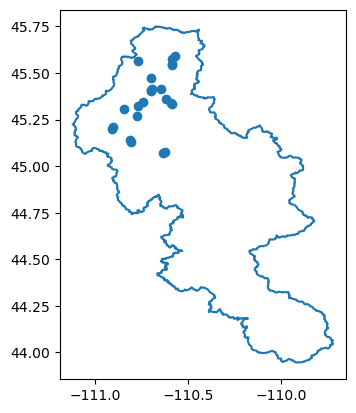

In [8]:
import geopandas as gpd
uy = gpd.read_file(uy_basin_pth)
uy = uy.to_crs(4326)
ax = uy.boundary.plot()
uy_gages = stage.get_site_locations(geometry=uy_basin_pth)
uy_gages.plot(ax=ax)

In [22]:
fig = px.scatter_map(uy_gages,
                     lat=uy_gages.geometry.y,
                     lon=uy_gages.geometry.x,
                     hover_name='LocationCode',
                     zoom=6)
fig.show()

In [23]:
gl = ['43B 91820', '43B 09550', '43B 91550', '43B 89500', '43B 02950', '43B 91750', '43B 09510', '43B 91620', '43B 05950', '43B 01990', '43B 89480']
sub = uy_gages.loc[uy_gages['LocationCode'].isin(gl),:]

In [25]:
sub = sub.set_crs(4326)
sub.to_file('D:/ArcGIS_Projects/Yellowstone/Upper Yellowstone/Vector/UY_prms_gages.shp')

C:\Users\CNB968\AppData\Local\Temp\ipykernel_26020\813353724.py:2: UserWarning:

Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.

c:\Users\CNB968\.conda\envs\MTDNRCdata\lib\site-packages\pyogrio\raw.py:709: RuntimeWarning:

Normalized/laundered field name: 'LocationCode' to 'LocationCo'

c:\Users\CNB968\.conda\envs\MTDNRCdata\lib\site-packages\pyogrio\raw.py:709: RuntimeWarning:

Normalized/laundered field name: 'LocationName' to 'LocationNa'

c:\Users\CNB968\.conda\envs\MTDNRCdata\lib\site-packages\pyogrio\raw.py:709: RuntimeWarning:

Normalized/laundered field name: 'LocationPath' to 'LocationPa'

c:\Users\CNB968\.conda\envs\MTDNRCdata\lib\site-packages\pyogrio\raw.py:709: RuntimeWarning:

Normalized/laundered field name: 'LocationType' to 'LocationTy'

c:\Users\CNB968\.conda\envs\MTDNRCdata\lib\site-packages\pyogrio\raw.py:709: RuntimeWarning:

Normalized/laundered field name: 'IsExternalLocation' to 'IsExternal'

c:\Users\CNB968\.conda\envs\MT